# 01 — Screening catalyst candidates with a linear mixed model

A catalyst screen often spans several synthesis or reactor batches.
Measurements made in the same batch share conditions that are hard to
reproduce exactly. A linear mixed model (LMM) separates candidate and
temperature effects from batch-to-batch variation.

## Learning objectives

By the end of this notebook you will be able to:

1. create a deterministic, balanced catalyst-screening data set;
2. distinguish fixed effects from a random batch intercept;
3. inspect a model before fitting it;
4. fit a Gaussian LMM with REML;
5. check convergence, estimates, residuals, and provenance; and
6. state what the model does **not** establish.

The data are synthetic and are designed for learning, not for a
scientific claim about any real catalyst.

## How to use this notebook

Run cells from top to bottom. Each section first explains the scientific
question and then shows the corresponding Python. No shell commands,
notebook magics, R code, or hidden data files are required.

In [1]:
import importlib
import logging
from pprint import pprint

import numpy as np

import pymixef

# Keep first-run Matplotlib font-cache status out of committed showcase output.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

print("PyMixEF version:", pymixef.__version__)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 10,
        "axes.titleweight": "semibold",
    }
)

PyMixEF version: 0.1.0


## 1. Design a balanced screen

We test five candidates in 12 batches. Every batch contains every
candidate at two temperatures, so candidate identity is not confounded
with temperature. The synthetic response is percent product yield.

The data-generating process contains:

- a candidate-specific yield shift;
- a common temperature slope;
- one shared random offset for each batch; and
- independent measurement noise.

A fixed random seed makes the generated table exactly reproducible.

In [2]:
rng = np.random.default_rng(20260723)

candidate_levels = np.array(["Cat-A", "Cat-B", "Cat-C", "Cat-D", "Cat-E"])
n_batches = 12
runs_per_batch = len(candidate_levels) * 2

candidate = np.tile(np.repeat(candidate_levels, 2), n_batches)
batch = np.repeat(
    [f"batch-{index + 1:02d}" for index in range(n_batches)],
    runs_per_batch,
)
nominal_temperature = np.tile(
    np.tile([310.0, 330.0], len(candidate_levels)),
    n_batches,
)
temperature_c = nominal_temperature + rng.normal(0.0, 1.0, candidate.size)
temperature_centered = temperature_c - 320.0

true_candidate_effect = {
    "Cat-A": 0.0,
    "Cat-B": 3.0,
    "Cat-C": -1.5,
    "Cat-D": 5.5,
    "Cat-E": 1.8,
}
batch_effect = rng.normal(0.0, 2.2, n_batches)
yield_pct = np.array(
    [
        58.0
        + true_candidate_effect[name]
        + 0.12 * centered_temperature
        + batch_effect[row // runs_per_batch]
        + rng.normal(0.0, 1.4)
        for row, (name, centered_temperature) in enumerate(
            zip(candidate, temperature_centered, strict=True)
        )
    ]
)

screening_data = {
    "yield_pct": yield_pct,
    "candidate": candidate,
    "temperature_centered": temperature_centered,
    "batch": batch,
}

print("Rows:", len(yield_pct))
print("Batches:", len(set(batch.tolist())))
print("Candidates:", sorted(set(candidate.tolist())))

Rows: 120
Batches: 12
Candidates: ['Cat-A', 'Cat-B', 'Cat-C', 'Cat-D', 'Cat-E']


A quick descriptive check is useful before modeling. These raw means do
not adjust for temperature or batch, but they can expose obvious data
construction mistakes.

In [3]:
def means_by_level(labels, values):
    return {
        level: float(np.mean(values[labels == level])) for level in sorted(set(labels.tolist()))
    }


print("Raw mean yield by candidate:")
pprint(means_by_level(candidate, yield_pct))
print("\nFirst five rows:")
for row in range(5):
    print({name: np.asarray(column)[row].item() for name, column in screening_data.items()})

Raw mean yield by candidate:
{'Cat-A': 58.689169095964964,
 'Cat-B': 61.52743711383783,
 'Cat-C': 57.07915965876316,
 'Cat-D': 63.51041302520153,
 'Cat-E': 60.046199645773015}

First five rows:
{'yield_pct': 56.32517632054916, 'candidate': 'Cat-A', 'temperature_centered': -10.06386135136438, 'batch': 'batch-01'}
{'yield_pct': 60.57891562540651, 'candidate': 'Cat-A', 'temperature_centered': 9.382904753519995, 'batch': 'batch-01'}
{'yield_pct': 61.45451241821404, 'candidate': 'Cat-B', 'temperature_centered': -11.752536996045876, 'batch': 'batch-01'}
{'yield_pct': 61.705063348018015, 'candidate': 'Cat-B', 'temperature_centered': 10.657254238897053, 'batch': 'batch-01'}
{'yield_pct': 55.73878478932225, 'candidate': 'Cat-C', 'temperature_centered': -9.623602284479091, 'batch': 'batch-01'}


## 2. Translate the scientific design into a model

We use:

\[
y_{ij} = \beta_0 + \beta_{candidate(i)}
         + \beta_T(T_{ij}-320) + b_j + \epsilon_{ij},
\]

where \(b_j\) is a batch-specific random intercept.

- **Fixed effects** (`candidate`, `temperature_centered`) answer questions
  about systematic differences in this designed screen.
- The **random effect** `(1 | batch)` represents a distribution of batch
  offsets and accounts for correlation among runs from the same batch.
- Centering temperature makes the intercept describe a run near 320 °C.

PyMixEF deterministically sorts string factor levels, so `Cat-A` is the
reference candidate in this data set.

In [4]:
lmm_model = pymixef.Model.from_formula("yield_pct ~ candidate + temperature_centered + (1 | batch)")

print(lmm_model.explain(screening_data, engine="lmm", method="reml"))

Formula: yield_pct ~ candidate + temperature_centered + (1 | batch)
Response: yield_pct (120 analysis rows)
Fixed design: X(120, 6), rank=6, columns=['Intercept', 'candidate[Cat-B]', 'candidate[Cat-C]', 'candidate[Cat-D]', 'candidate[Cat-E]', 'temperature_centered']
Random designs:
  batch: Z(120, 1), groups=12, covariance=unstructured
Excluded source rows: 0
Family: gaussian (identity link)
Engine: lmm; method: reml
Compatibility: valid


## 3. Compile before fitting

Compilation creates model matrices, audits rows, records factor coding,
and validates engine compatibility. This dry-run stage is a good place
to catch misspelled columns, missing values, or an unsupported method.

In [5]:
lmm_plan = lmm_model.compile(
    screening_data,
    engine="lmm",
    method="reml",
)

print(lmm_plan.explain())
print("\nAnalysis rows:", lmm_plan.matrices.audit.analysis_rows)
print("Excluded rows:", lmm_plan.matrices.audit.excluded_rows)
print("Factor levels:", dict(lmm_plan.matrices.factor_levels))

Formula: yield_pct ~ candidate + temperature_centered + (1 | batch)
Response: yield_pct (120 analysis rows)
Fixed design: X(120, 6), rank=6, columns=['Intercept', 'candidate[Cat-B]', 'candidate[Cat-C]', 'candidate[Cat-D]', 'candidate[Cat-E]', 'temperature_centered']
Random designs:
  batch: Z(120, 1), groups=12, covariance=unstructured
Excluded source rows: 0
Family: gaussian (identity link)
Engine: lmm; method: reml
Model IR: 5a59a9408c88b75bc84c3c90ce404f7015adc7587bff8c30b506fc7d3962ab26
Data audit: 120 input, 120 analysis, 0 excluded; reasons={'DATA-RETAINED-001': 120}

Analysis rows: 120
Excluded rows: 0
Factor levels: {'candidate': ('Cat-A', 'Cat-B', 'Cat-C', 'Cat-D', 'Cat-E')}


## 4. Fit with restricted maximum likelihood

REML is the default Gaussian mixed-model method here. The backend is a
dense reference implementation, appropriate for examples and validation
but not a claim of large-scale production performance.

In [6]:
lmm_fit = lmm_plan.fit()
print(lmm_fit.summary())

PyMixEF fit (lmm, reml)
Observations: 120
Objective: 214.2828458
Log likelihood: -214.2828458
Convergence: converged
Parameters:
  Intercept              58.684
  candidate[Cat-B]       2.8514156
  candidate[Cat-C]      -1.6116593
  candidate[Cat-D]       4.822573
  candidate[Cat-E]       1.3997815
  temperature_centered   0.10697222
  sd(batch:Intercept)    1.2156778
  residual_sd            1.268711


## 5. Check convergence before interpreting coefficients

A printed parameter table is not enough. We inspect the structured
convergence report and any warning codes first.

In [7]:
convergence = lmm_fit.convergence
pprint(
    {
        "status": convergence.status,
        "trustworthy": convergence.trustworthy,
        "optimizer_terminated": convergence.optimizer_terminated,
        "iterations": convergence.iterations,
        "scaled_gradient_inf_norm": convergence.scaled_gradient_inf_norm,
        "hessian_positive_definite": convergence.hessian.positive_definite,
        "warning_codes": [warning.code for warning in convergence.warnings],
    }
)

assert convergence.trustworthy, "Review convergence before interpretation."

{'hessian_positive_definite': True,
 'iterations': 1,
 'optimizer_terminated': True,
 'scaled_gradient_inf_norm': 5.684341889072788e-06,
 'status': 'converged',
 'trustworthy': True,
 'warning_codes': []}


## 6. Interpret fixed effects and uncertainty

Candidate coefficients are adjusted differences from `Cat-A` at 320 °C.
The temperature coefficient is the expected yield change per 1 °C.
Standard deviations describe batch heterogeneity and residual scatter;
they are not candidate effects.

The next table reports approximate Wald standard errors from the
archived fixed-effect covariance matrix.

In [8]:
fixed_names = list(lmm_fit.extra["fixed_effect_names"])
fixed_covariance = np.asarray(lmm_fit.extra["fixed_effect_covariance"])
fixed_standard_errors = np.sqrt(np.diag(fixed_covariance))

print(f"{'fixed effect':32s} {'estimate':>12s} {'std. error':>12s}")
for name, standard_error in zip(fixed_names, fixed_standard_errors, strict=True):
    print(f"{name:32s} {lmm_fit.parameters[name]:12.4f} {standard_error:12.4f}")

fixed effect                         estimate   std. error
Intercept                             58.6840       0.4361
candidate[Cat-B]                       2.8514       0.3662
candidate[Cat-C]                      -1.6117       0.3662
candidate[Cat-D]                       4.8226       0.3662
candidate[Cat-E]                       1.3998       0.3663
temperature_centered                   0.1070       0.0117


## 7. Rank adjusted candidate means at the centered temperature

Because this model has no candidate-by-temperature interaction, the
adjusted candidate difference is constant across temperature. The code
below evaluates fixed effects at 320 °C and a batch random effect of
zero. It is a population-level comparison, not a prediction for a
particular future batch.

In [9]:
reference_mean = lmm_fit.parameters["Intercept"]
adjusted_candidate_mean = {}
for name in candidate_levels:
    coefficient_name = f"candidate[{name}]"
    adjusted_candidate_mean[name] = reference_mean + lmm_fit.parameters.get(coefficient_name, 0.0)

ranking = sorted(
    adjusted_candidate_mean.items(),
    key=lambda item: item[1],
    reverse=True,
)
assert ranking[0][0] == "Cat-D", "The synthetic screen should rank Cat-D first."
assert adjusted_candidate_mean["Cat-D"] > adjusted_candidate_mean["Cat-A"]
assert adjusted_candidate_mean["Cat-C"] < adjusted_candidate_mean["Cat-A"]
print("Adjusted mean yield at 320 °C and average batch:")
for rank, (name, estimate) in enumerate(ranking, start=1):
    print(f"{rank}. {name}: {estimate:.2f}%")

Adjusted mean yield at 320 °C and average batch:
1. Cat-D: 63.51%
2. Cat-B: 61.54%
3. Cat-E: 60.08%
4. Cat-A: 58.68%
5. Cat-C: 57.07%


### Figure: adjusted candidate means with uncertainty

The point-range chart puts the adjusted comparison on the response scale.
Intervals are approximate 95% Wald intervals calculated from the full fixed-effect
covariance matrix.

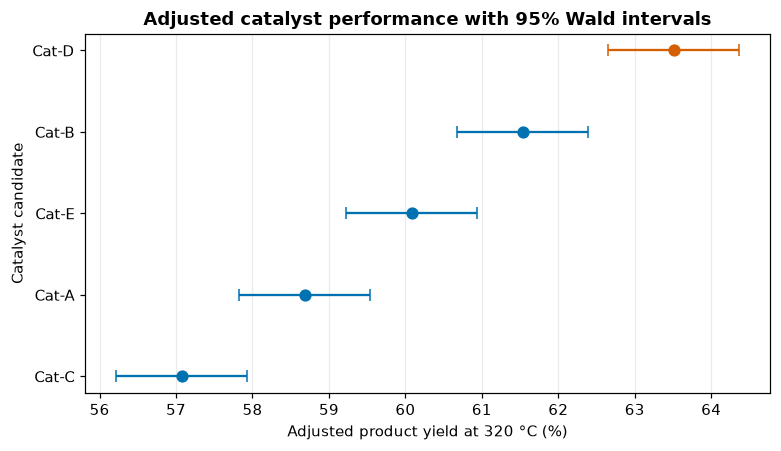

In [10]:
candidate_design = np.zeros((len(candidate_levels), len(fixed_names)))
candidate_design[:, fixed_names.index("Intercept")] = 1.0
for row, name in enumerate(candidate_levels):
    coefficient_name = f"candidate[{name}]"
    if coefficient_name in fixed_names:
        candidate_design[row, fixed_names.index(coefficient_name)] = 1.0

fixed_estimate_vector = np.array([lmm_fit.parameters[name] for name in fixed_names])
candidate_estimate = candidate_design @ fixed_estimate_vector
candidate_standard_error = np.sqrt(
    np.einsum(
        "ij,jk,ik->i",
        candidate_design,
        fixed_covariance,
        candidate_design,
    )
)
display_order = np.argsort(candidate_estimate)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for position, row in enumerate(display_order):
    name = candidate_levels[row]
    color = "#D55E00" if name == ranking[0][0] else "#0072B2"
    ax.errorbar(
        candidate_estimate[row],
        position,
        xerr=1.96 * candidate_standard_error[row],
        fmt="o",
        color=color,
        capsize=4,
        markersize=7,
    )
ax.set_yticks(
    np.arange(len(display_order)),
    labels=[candidate_levels[row] for row in display_order],
)
ax.set_xlabel("Adjusted product yield at 320 °C (%)")
ax.set_ylabel("Catalyst candidate")
ax.set_title("Adjusted catalyst performance with 95% Wald intervals")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

**Interpretation.** `Cat-D` has the highest adjusted mean in this deterministic
screen. The intervals communicate estimation precision; planned pairwise contrasts
remain the appropriate basis for a formal candidate comparison.

### Figure: observed yield and fitted temperature trends

Population-level fitted lines show the model-implied candidate trends while the
semi-transparent markers retain the observed experimental spread.

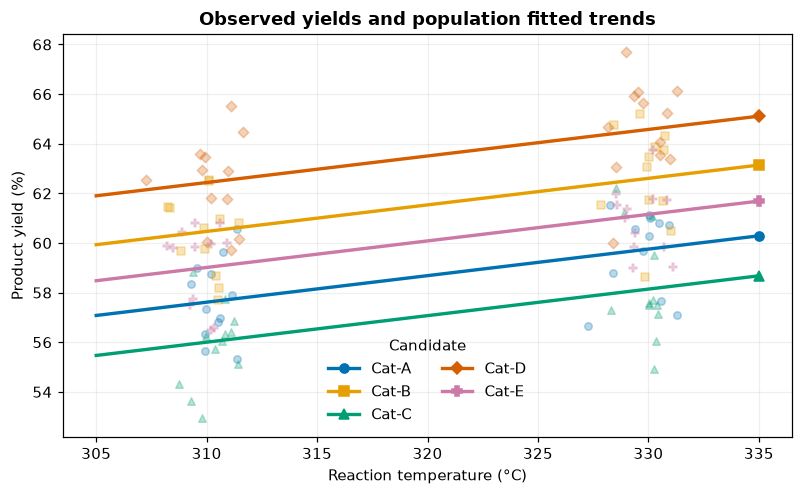

In [11]:
temperature_grid = np.linspace(305.0, 335.0, 100)
palette = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]
markers = ["o", "s", "^", "D", "P"]

fig, ax = plt.subplots(figsize=(7.4, 4.6))
for name, color, marker in zip(candidate_levels, palette, markers, strict=True):
    selected = candidate == name
    ax.scatter(
        temperature_c[selected],
        yield_pct[selected],
        color=color,
        marker=marker,
        alpha=0.28,
        s=24,
    )
    fitted_line = adjusted_candidate_mean[name] + lmm_fit.parameters["temperature_centered"] * (
        temperature_grid - 320.0
    )
    ax.plot(
        temperature_grid,
        fitted_line,
        color=color,
        linewidth=2.2,
        marker=marker,
        markevery=[-1],
        label=name,
    )
ax.set_xlabel("Reaction temperature (°C)")
ax.set_ylabel("Product yield (%)")
ax.set_title("Observed yields and population fitted trends")
ax.legend(title="Candidate", ncol=2, frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** The fitted lines are parallel because this model includes one
common temperature slope and no candidate-by-temperature interaction. The observed
scatter also shows the batch and measurement variation modeled elsewhere.

## 8. Examine fitted values and residuals

Conditional fitted values include estimated batch effects. Population
fitted values set the batch effect to zero. Their difference illustrates
why prediction mode should always be named explicitly.

In [12]:
conditional = lmm_fit.prediction(mode="conditional")
population = lmm_fit.prediction(mode="population")
observed = np.asarray(screening_data["yield_pct"])

conditional_rmse = float(np.sqrt(np.mean((observed - conditional) ** 2)))
population_rmse = float(np.sqrt(np.mean((observed - population) ** 2)))
assert np.all(np.isfinite(conditional)) and np.all(np.isfinite(population))
assert np.isfinite(conditional_rmse) and np.isfinite(population_rmse)
assert conditional_rmse < population_rmse
print("Conditional RMSE:", round(conditional_rmse, 3))
print("Population RMSE:", round(population_rmse, 3))

residual_table = lmm_fit.residual_diagnostics()
print("Residual diagnostic columns:", list(residual_table.columns))
print(
    "Mean response residual:",
    round(float(np.mean(residual_table.columns["raw_residual"])), 6),
)

Conditional RMSE: 1.182
Population RMSE: 1.698
Residual diagnostic columns: ['row_id', 'observed', 'fitted', 'raw_residual', 'pearson_residual']
Mean response residual: -0.0


### Figure: residuals versus conditional fitted yield

This plot checks whether residual spread or curvature changes systematically across
the fitted response range.

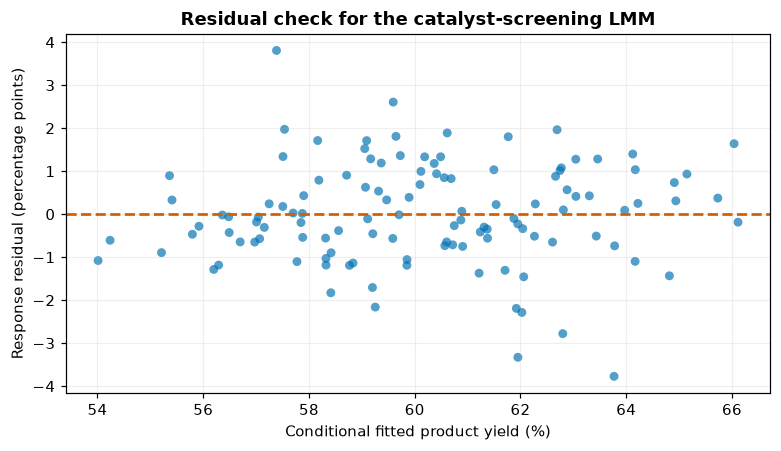

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.scatter(
    conditional,
    lmm_fit.residuals,
    color="#0072B2",
    edgecolor="none",
    alpha=0.68,
    s=34,
)
ax.axhline(0.0, color="#D55E00", linewidth=1.8, linestyle="--")
ax.set_xlabel("Conditional fitted product yield (%)")
ax.set_ylabel("Response residual (percentage points)")
ax.set_title("Residual check for the catalyst-screening LMM")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** Residuals remain centered near zero without a strong visual
curve or funnel in this synthetic example. A real screen would pair this view with
influence checks and prespecified sensitivity analyses.

## 9. Audit and provenance

PyMixEF archives the semantic model, data fingerprint, settings,
convergence information, and output hashes. These records support
reproducibility; they do not certify scientific validity.

In [14]:
manifest = lmm_fit.manifest.to_dict()
pprint(
    {
        key: manifest[key]
        for key in (
            "package_version",
            "engine",
            "method",
            "model_ir_hash",
            "data_hash",
            "reproducibility_class",
        )
    }
)
print("Recorded optimizer sequence:")
pprint(manifest["settings"]["optimizer_sequence"])

{'data_hash': 'sha256:3906be62f39553639b973c2cba67421cc44f47e54064ed730cc46250262333a7',
 'engine': 'lmm',
 'method': 'reml',
 'model_ir_hash': 'sha256:5a59a9408c88b75bc84c3c90ce404f7015adc7587bff8c30b506fc7d3962ab26',
 'package_version': '0.1.0',
 'reproducibility_class': 'deterministic-with-tolerance'}
Recorded optimizer sequence:
['L-BFGS-B', 'Powell rescue', 'L-BFGS-B refinement']


## Interpretation

In this synthetic realization, `Cat-D` has the largest adjusted mean,
and positive batch variation remains after accounting for candidate and
temperature. The fitted values recover the broad data-generating pattern,
but estimates differ from the known synthetic values because samples are
finite.

A real decision would also require uncertainty intervals for planned
contrasts, robustness checks, physical characterization, and independent
confirmation experiments.

## Scope note

This showcase is intentionally centered on a balanced Gaussian screen with
a random batch intercept. For a discovery decision, extend the same audited
workflow with planned contrasts, candidate-by-temperature sensitivity,
durability and selectivity measurements, missing-data reasoning, and
independent confirmation so conclusions respect the experiment's
limitations and intended transport range.

## Exercises

1. Add a `candidate * temperature_centered` interaction. Which candidates
   are most temperature-sensitive?
2. Increase the synthetic batch standard deviation from 2.2 to 5.0 and
   compare conditional with population RMSE.
3. Delete several response values and compare `missing="drop"` with
   `missing="raise"` during compilation.
4. Fit with ML instead of REML and explain why objective values should
   only be compared when conventions match.
5. Add replicate measurements and consider whether another grouping
   factor is scientifically justified.

## Takeaways

- Encode designed factors as fixed effects and shared nuisance variation
  as scientifically defensible random effects.
- Inspect and compile before fitting.
- Check convergence before estimates.
- Name the prediction mode.
- Treat the model as one piece of evidence in a materials-discovery
  workflow, not as an automated winner selector.